In [ ]:
import torch
import numpy as np
import random

SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# ---- Proper CICIDS Reload with Class Separation ----

import zipfile
import os
import pandas as pd

ZIP_PATH = "/content/CICIDS2017.zip"
EXTRACT_DIR = "/content/cicids_fixed"

# Extract again (safe even if already extracted)
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

csv_files = [os.path.join(EXTRACT_DIR, f)
             for f in os.listdir(EXTRACT_DIR)
             if f.endswith(".csv")]

print("CSV files found:", len(csv_files))

benign_list = []
attack_list = []

for f in csv_files:
    df_temp = pd.read_csv(f)

    # Identify label column
    label_col = [c for c in df_temp.columns if "category" in c.lower()][0]

    # Separate classes
    benign = df_temp[df_temp[label_col] == 0]
    attack = df_temp[df_temp[label_col] != 0]

    benign_list.append(benign)
    attack_list.append(attack)

# Combine all benign and attack samples
benign_df = pd.concat(benign_list, ignore_index=True)
attack_df = pd.concat(attack_list, ignore_index=True)

print("Total benign:", len(benign_df))
print("Total attack:", len(attack_df))

CSV files found: 10
Total benign: 9690
Total attack: 4190252


In [ ]:
# ---- Create Balanced Dataset ----

min_class_size = min(len(benign_df), len(attack_df))

benign_sampled = benign_df.sample(min_class_size, random_state=42)
attack_sampled = attack_df.sample(min_class_size, random_state=42)

balanced_df = pd.concat([benign_sampled, attack_sampled])
balanced_df = balanced_df.sample(frac=1, random_state=42)  # shuffle

print("Balanced dataset size:", balanced_df.shape)
print(balanced_df["Attempted Category"].apply(lambda x: 0 if x==0 else 1).value_counts())

Balanced dataset size: (19380, 105)
Attempted Category
1    9690
0    9690
Name: count, dtype: int64


In [ ]:
import numpy as np

# Create binary label
balanced_df["binary_label"] = balanced_df["Attempted Category"].apply(
    lambda x: 0 if x == 0 else 1
)

# Drop non-feature columns
drop_cols = ["Attempted Category", "Flow ID"]
drop_cols += [c for c in balanced_df.columns if c.startswith("Local")]

balanced_df = balanced_df.drop(columns=drop_cols)

# Remove inf and NaN
balanced_df = balanced_df.replace([np.inf, -np.inf], np.nan)
balanced_df = balanced_df.dropna()

# Final X and y
X = balanced_df.drop(columns=["binary_label"]).values
y = balanced_df["binary_label"].values

print("Final X shape:", X.shape)
print("Final y distribution:", np.bincount(y))

Final X shape: (19380, 88)
Final y distribution: [9690 9690]


In [ ]:
# Keep only numeric columns
balanced_df = balanced_df.select_dtypes(include=['number'])

print("Remaining columns:", balanced_df.shape[1])

Remaining columns: 87


In [ ]:
X = balanced_df.drop(columns=["binary_label"]).values
y = balanced_df["binary_label"].values

print("New X shape:", X.shape)

New X shape: (19380, 86)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (15504, 86)
Test shape: (3876, 86)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
import numpy as np

NUM_CLIENTS = 5

client_data = []

split_size = len(X_train) // NUM_CLIENTS

for i in range(NUM_CLIENTS):
    start = i * split_size
    end = (i + 1) * split_size
    client_data.append(
        (X_train[start:end], y_train[start:end])
    )

print("Clients created:", len(client_data))

Clients created: 5


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class FLModel(nn.Module):
    def __init__(self, input_dim):
        super(FLModel, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
import torch

# Convert test set to torch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Convert client data to tensors
client_tensors = []

for X_c, y_c in client_data:
    X_c = torch.tensor(X_c, dtype=torch.float32)
    y_c = torch.tensor(y_c, dtype=torch.long)
    client_tensors.append((X_c, y_c))

print("Client tensor preparation complete")

Client tensor preparation complete


In [ ]:
def local_train(model, X, y, epochs=2, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    model.train()

    for _ in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

    return model.state_dict()

In [ ]:
def fedavg(global_model, client_states):
    global_dict = global_model.state_dict()

    for key in global_dict.keys():
        global_dict[key] = torch.stack(
            [client_state[key] for client_state in client_states],
            dim=0
        ).mean(dim=0)

    global_model.load_state_dict(global_dict)
    return global_model

In [ ]:
NUM_ROUNDS = 20
input_dim = X_train.shape[1]

global_model = FLModel(input_dim)

accuracy_per_round = []

for round_num in range(NUM_ROUNDS):

    client_states = []

    # Send model to each client
    for X_c, y_c in client_tensors:
        local_model = FLModel(input_dim)
        local_model.load_state_dict(global_model.state_dict())

        updated_state = local_train(local_model, X_c, y_c)
        client_states.append(updated_state)

    # Aggregate
    global_model = fedavg(global_model, client_states)

    # Evaluate
    global_model.eval()
    with torch.no_grad():
        outputs = global_model(X_test_tensor)
        _, preds = torch.max(outputs, 1)
        acc = (preds == y_test_tensor).float().mean().item()

    accuracy_per_round.append(acc)

    print(f"Round {round_num+1} - Global Accuracy: {acc:.4f}")
iid_model = FLModel(input_dim)
iid_model.load_state_dict(global_model.state_dict())

Round 1 - Global Accuracy: 0.5018
Round 2 - Global Accuracy: 0.5031
Round 3 - Global Accuracy: 0.5067
Round 4 - Global Accuracy: 0.5119
Round 5 - Global Accuracy: 0.5191
Round 6 - Global Accuracy: 0.5338
Round 7 - Global Accuracy: 0.5537
Round 8 - Global Accuracy: 0.5996
Round 9 - Global Accuracy: 0.6711
Round 10 - Global Accuracy: 0.6966
Round 11 - Global Accuracy: 0.7098
Round 12 - Global Accuracy: 0.7214
Round 13 - Global Accuracy: 0.7255
Round 14 - Global Accuracy: 0.7309
Round 15 - Global Accuracy: 0.7343
Round 16 - Global Accuracy: 0.7384
Round 17 - Global Accuracy: 0.7356
Round 18 - Global Accuracy: 0.7407
Round 19 - Global Accuracy: 0.7389
Round 20 - Global Accuracy: 0.7296


<All keys matched successfully>

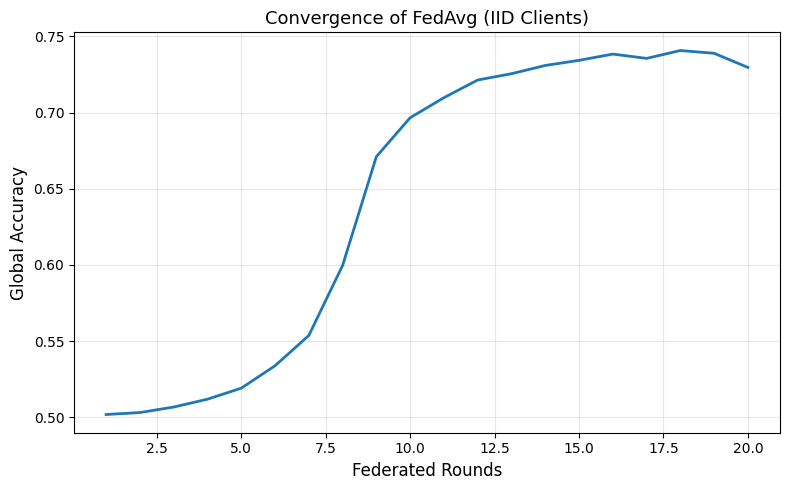

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1),
         accuracy_per_round,
         linewidth=2)

plt.xlabel("Federated Rounds", fontsize=12)
plt.ylabel("Global Accuracy", fontsize=12)
plt.title("Convergence of FedAvg (IID Clients)", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Separate train data by class
X_train_np = X_train
y_train_np = y_train

benign_idx = np.where(y_train_np == 0)[0]
attack_idx = np.where(y_train_np == 1)[0]

print("Total benign in train:", len(benign_idx))
print("Total attack in train:", len(attack_idx))

Total benign in train: 7752
Total attack in train: 7752


In [ ]:
NUM_CLIENTS = 5

skew_config = [
    (0.9, 0.1),  # Client 1
    (0.1, 0.9),  # Client 2
    (0.7, 0.3),  # Client 3
    (0.3, 0.7),  # Client 4
    (0.5, 0.5)   # Client 5
]

In [ ]:
client_data_noniid = []

total_per_client = len(X_train_np) // NUM_CLIENTS

for i in range(NUM_CLIENTS):

    benign_ratio, attack_ratio = skew_config[i]

    num_benign = int(total_per_client * benign_ratio)
    num_attack = total_per_client - num_benign

    selected_benign = np.random.choice(benign_idx, num_benign, replace=False)
    selected_attack = np.random.choice(attack_idx, num_attack, replace=False)

    selected_indices = np.concatenate([selected_benign, selected_attack])
    np.random.shuffle(selected_indices)

    X_c = torch.tensor(X_train_np[selected_indices], dtype=torch.float32)
    y_c = torch.tensor(y_train_np[selected_indices], dtype=torch.long)

    client_data_noniid.append((X_c, y_c))

print("Non-IID clients created:", len(client_data_noniid))

Non-IID clients created: 5


In [ ]:
accuracy_noniid = []

NUM_ROUNDS = 20
input_dim = X_train.shape[1]

global_model = FLModel(input_dim)

for round_num in range(NUM_ROUNDS):

    client_states = []

    for X_c, y_c in client_data_noniid:

        local_model = FLModel(input_dim)
        local_model.load_state_dict(global_model.state_dict())

        updated_state = local_train(local_model, X_c, y_c)
        client_states.append(updated_state)

    global_model = fedavg(global_model, client_states)

    global_model.eval()
    with torch.no_grad():
        outputs = global_model(X_test_tensor)
        _, preds = torch.max(outputs, 1)
        acc = (preds == y_test_tensor).float().mean().item()

    accuracy_noniid.append(acc)   # 🔥 THIS LINE IS CRITICAL

    print(f"Round {round_num+1} - Global Accuracy: {acc:.4f}")
noniid_model = FLModel(input_dim)
noniid_model.load_state_dict(global_model.state_dict())

Round 1 - Global Accuracy: 0.4747
Round 2 - Global Accuracy: 0.4765
Round 3 - Global Accuracy: 0.4819
Round 4 - Global Accuracy: 0.4827
Round 5 - Global Accuracy: 0.4848
Round 6 - Global Accuracy: 0.4853
Round 7 - Global Accuracy: 0.4863
Round 8 - Global Accuracy: 0.4977
Round 9 - Global Accuracy: 0.4997
Round 10 - Global Accuracy: 0.5008
Round 11 - Global Accuracy: 0.5013
Round 12 - Global Accuracy: 0.5021
Round 13 - Global Accuracy: 0.5031
Round 14 - Global Accuracy: 0.5034
Round 15 - Global Accuracy: 0.5064
Round 16 - Global Accuracy: 0.5062
Round 17 - Global Accuracy: 0.5072
Round 18 - Global Accuracy: 0.5072
Round 19 - Global Accuracy: 0.5080
Round 20 - Global Accuracy: 0.5085


<All keys matched successfully>

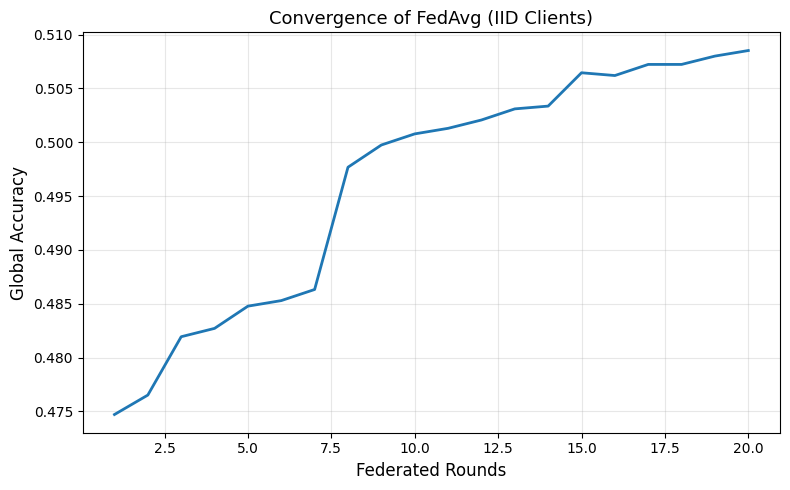

In [ ]:

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1),
         accuracy_noniid,
         linewidth=2)

plt.xlabel("Federated Rounds", fontsize=12)
plt.ylabel("Global Accuracy", fontsize=12)
plt.title("Convergence of FedAvg (IID Clients)", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(type(accuracy_noniid))
print(accuracy_noniid)

<class 'list'>
[0.4819401502609253, 0.4840041399002075, 0.48606809973716736, 0.4868420958518982, 0.4889060854911804, 0.49097007513046265, 0.49200206995010376, 0.494066059589386, 0.4950980246067047, 0.4966460168361664, 0.4966460168361664, 0.49690401554107666, 0.4976780116558075, 0.4989680051803589, 0.5005159974098206, 0.5007739663124084, 0.501289963722229, 0.5175438523292542, 0.5446336269378662, 0.5694014430046082]


In [ ]:
NUM_BYZANTINE = 2

In [ ]:
def generate_random_weights(model):
    random_state = {}
    for key, value in model.state_dict().items():
        random_state[key] = torch.randn_like(value)
    return random_state

In [ ]:
accuracy_byzantine = []

NUM_ROUNDS = 20
input_dim = X_train.shape[1]

global_model = FLModel(input_dim)

for round_num in range(NUM_ROUNDS):

    client_states = []

    for i, (X_c, y_c) in enumerate(client_data_noniid):

        # If client is Byzantine
        if i < NUM_BYZANTINE:
            malicious_state = generate_random_weights(global_model)
            client_states.append(malicious_state)

        else:
            local_model = FLModel(input_dim)
            local_model.load_state_dict(global_model.state_dict())

            updated_state = local_train(local_model, X_c, y_c)
            client_states.append(updated_state)

    # Aggregate
    global_model = fedavg(global_model, client_states)

    # Evaluate
    global_model.eval()
    with torch.no_grad():
        outputs = global_model(X_test_tensor)
        _, preds = torch.max(outputs, 1)
        acc = (preds == y_test_tensor).float().mean().item()

    accuracy_byzantine.append(acc)

    print(f"Round {round_num+1} - Global Accuracy: {acc:.4f}")
byz_model = FLModel(input_dim)
byz_model.load_state_dict(global_model.state_dict())

Round 1 - Global Accuracy: 0.2683
Round 2 - Global Accuracy: 0.5015
Round 3 - Global Accuracy: 0.6280
Round 4 - Global Accuracy: 0.3078
Round 5 - Global Accuracy: 0.5583
Round 6 - Global Accuracy: 0.5062
Round 7 - Global Accuracy: 0.5181
Round 8 - Global Accuracy: 0.5526
Round 9 - Global Accuracy: 0.6520
Round 10 - Global Accuracy: 0.5668
Round 11 - Global Accuracy: 0.5681
Round 12 - Global Accuracy: 0.2510
Round 13 - Global Accuracy: 0.5552
Round 14 - Global Accuracy: 0.5134
Round 15 - Global Accuracy: 0.6133
Round 16 - Global Accuracy: 0.3991
Round 17 - Global Accuracy: 0.4203
Round 18 - Global Accuracy: 0.4845
Round 19 - Global Accuracy: 0.4164
Round 20 - Global Accuracy: 0.4701


<All keys matched successfully>

In [ ]:
print(type(accuracy_byzantine))
print(accuracy_byzantine)

<class 'list'>
[0.3975748121738434, 0.36558306217193604, 0.6145510673522949, 0.5433436632156372, 0.3648090958595276, 0.2618679106235504, 0.5474716424942017, 0.5221878290176392, 0.8402992486953735, 0.400928795337677, 0.4809081554412842, 0.5077399611473083, 0.5025799870491028, 0.5521155595779419, 0.6184210777282715, 0.5820433497428894, 0.5278638005256653, 0.5732713937759399, 0.6207430362701416, 0.49432405829429626]


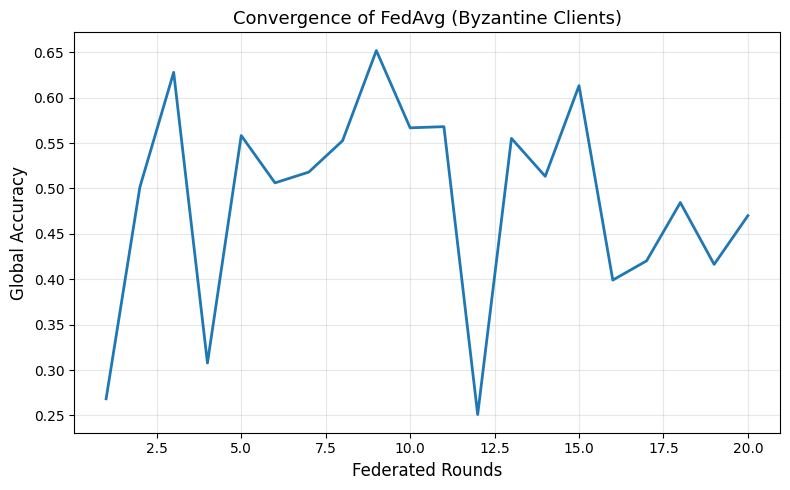

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1),
         accuracy_byzantine,
         linewidth=2)

plt.xlabel("Federated Rounds", fontsize=12)
plt.ylabel("Global Accuracy", fontsize=12)
plt.title("Convergence of FedAvg (Byzantine Clients)", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

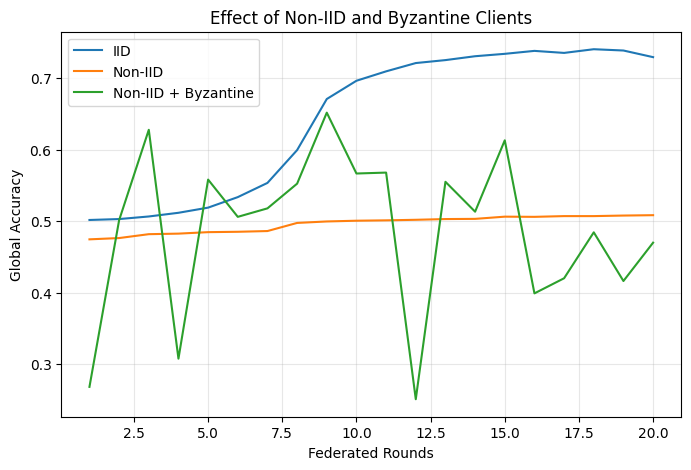

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1), accuracy_per_round, label="IID")
plt.plot(range(1, NUM_ROUNDS+1), accuracy_noniid, label="Non-IID")
plt.plot(range(1, NUM_ROUNDS+1), accuracy_byzantine, label="Non-IID + Byzantine")

plt.xlabel("Federated Rounds")
plt.ylabel("Global Accuracy")
plt.title("Effect of Non-IID and Byzantine Clients")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
def fed_median(global_model, client_states):
    global_dict = global_model.state_dict()

    for key in global_dict.keys():

        # Stack client weights for this layer
        stacked = torch.stack(
            [client_state[key] for client_state in client_states],
            dim=0
        )

        # Compute median across clients
        global_dict[key] = torch.median(stacked, dim=0).values

    global_model.load_state_dict(global_dict)
    return global_model

In [ ]:
accuracy_median = []

NUM_ROUNDS = 20
input_dim = X_train.shape[1]

global_model = FLModel(input_dim)

for round_num in range(NUM_ROUNDS):

    client_states = []

    for i, (X_c, y_c) in enumerate(client_data_noniid):

        # Byzantine clients
        if i < NUM_BYZANTINE:
            malicious_state = generate_random_weights(global_model)
            client_states.append(malicious_state)
        else:
            local_model = FLModel(input_dim)
            local_model.load_state_dict(global_model.state_dict())

            updated_state = local_train(local_model, X_c, y_c)
            client_states.append(updated_state)

    # 🔥 Use Median instead of FedAvg
    global_model = fed_median(global_model, client_states)

    # Evaluate
    global_model.eval()
    with torch.no_grad():
        outputs = global_model(X_test_tensor)
        _, preds = torch.max(outputs, 1)
        acc = (preds == y_test_tensor).float().mean().item()

    accuracy_median.append(acc)

    print(f"Round {round_num+1} - Global Accuracy: {acc:.4f}")
median_model = FLModel(input_dim)
median_model.load_state_dict(global_model.state_dict())

Round 1 - Global Accuracy: 0.5377
Round 2 - Global Accuracy: 0.5467
Round 3 - Global Accuracy: 0.5663
Round 4 - Global Accuracy: 0.5991
Round 5 - Global Accuracy: 0.6445
Round 6 - Global Accuracy: 0.6850
Round 7 - Global Accuracy: 0.6925
Round 8 - Global Accuracy: 0.7074
Round 9 - Global Accuracy: 0.7134
Round 10 - Global Accuracy: 0.7227
Round 11 - Global Accuracy: 0.7407
Round 12 - Global Accuracy: 0.7644
Round 13 - Global Accuracy: 0.7745
Round 14 - Global Accuracy: 0.7763
Round 15 - Global Accuracy: 0.7859
Round 16 - Global Accuracy: 0.7988
Round 17 - Global Accuracy: 0.8068
Round 18 - Global Accuracy: 0.8279
Round 19 - Global Accuracy: 0.8395
Round 20 - Global Accuracy: 0.8431


<All keys matched successfully>

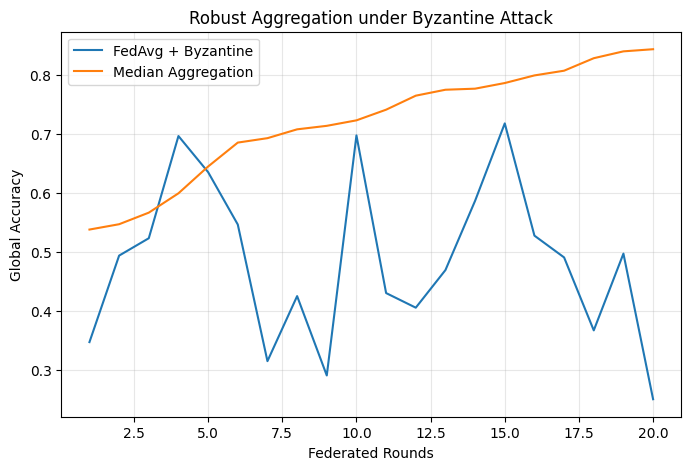

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1), accuracy_byzantine, label="FedAvg + Byzantine")
plt.plot(range(1, NUM_ROUNDS+1), accuracy_median, label="Median Aggregation")

plt.xlabel("Federated Rounds")
plt.ylabel("Global Accuracy")
plt.title("Robust Aggregation under Byzantine Attack")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

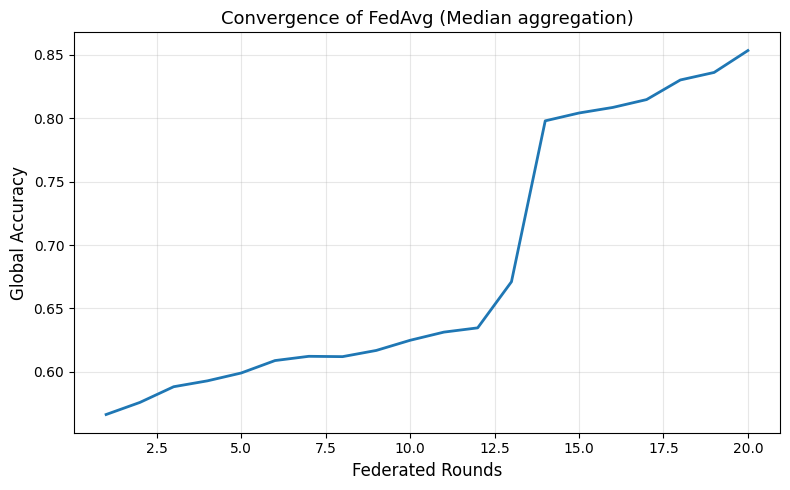

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1),
         accuracy_median,
         linewidth=2)

plt.xlabel("Federated Rounds", fontsize=12)
plt.ylabel("Global Accuracy", fontsize=12)
plt.title("Convergence of FedAvg (Median aggregation)", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
def flatten_model(state_dict):
    return torch.cat([v.flatten() for v in state_dict.values()])

In [ ]:
import torch.nn.functional as F

def compute_trust_scores_median_based(client_states):

    flattened = [flatten_model(cs) for cs in client_states]
    stacked = torch.stack(flattened)

    # Compute global median vector
    median_vector = torch.median(stacked, dim=0).values

    distances = torch.zeros(len(flattened))

    for i in range(len(flattened)):
        distances[i] = torch.norm(flattened[i] - median_vector, p=2)

    # Smaller distance → higher trust
    trust_scores = 1 / (distances + 1e-8)
    trust_scores = trust_scores / trust_scores.sum()

    return trust_scores

In [ ]:
def fed_trust_median(global_model, client_states):

    global_dict = global_model.state_dict()
    trust_scores = compute_trust_scores_median_based(client_states)

    for key in global_dict.keys():

        stacked = torch.stack(
            [client_state[key] for client_state in client_states],
            dim=0
        )

        weighted_sum = torch.zeros_like(global_dict[key])

        for i in range(len(client_states)):
            weighted_sum += trust_scores[i] * stacked[i]

        global_dict[key] = weighted_sum

    global_model.load_state_dict(global_dict)
    return global_model

In [ ]:
accuracy_trust = []

NUM_ROUNDS = 20
input_dim = X_train.shape[1]

global_model = FLModel(input_dim)

for round_num in range(NUM_ROUNDS):

    client_states = []

    for i, (X_c, y_c) in enumerate(client_data_noniid):

        if i < NUM_BYZANTINE:
            malicious_state = generate_random_weights(global_model)
            client_states.append(malicious_state)
        else:
            local_model = FLModel(input_dim)
            local_model.load_state_dict(global_model.state_dict())

            updated_state = local_train(local_model, X_c, y_c)
            client_states.append(updated_state)

    # 🔥 Trust aggregation
    global_model = fed_trust(global_model, client_states)

    # Evaluate
    global_model.eval()
    with torch.no_grad():
        outputs = global_model(X_test_tensor)
        _, preds = torch.max(outputs, 1)
        acc = (preds == y_test_tensor).float().mean().item()

    accuracy_trust.append(acc)

    print(f"Round {round_num+1} - Global Accuracy: {acc:.4f}")
trust_model = FLModel(input_dim)
trust_model.load_state_dict(global_model.state_dict())

Round 1 - Global Accuracy: 0.5240
Round 2 - Global Accuracy: 0.3021
Round 3 - Global Accuracy: 0.5243
Round 4 - Global Accuracy: 0.3767
Round 5 - Global Accuracy: 0.3243
Round 6 - Global Accuracy: 0.1984
Round 7 - Global Accuracy: 0.5524
Round 8 - Global Accuracy: 0.7515
Round 9 - Global Accuracy: 0.5439
Round 10 - Global Accuracy: 0.5126
Round 11 - Global Accuracy: 0.3800
Round 12 - Global Accuracy: 0.5036
Round 13 - Global Accuracy: 0.4727
Round 14 - Global Accuracy: 0.4678
Round 15 - Global Accuracy: 0.5490
Round 16 - Global Accuracy: 0.4853
Round 17 - Global Accuracy: 0.6690
Round 18 - Global Accuracy: 0.7577
Round 19 - Global Accuracy: 0.6507
Round 20 - Global Accuracy: 0.8351


<All keys matched successfully>

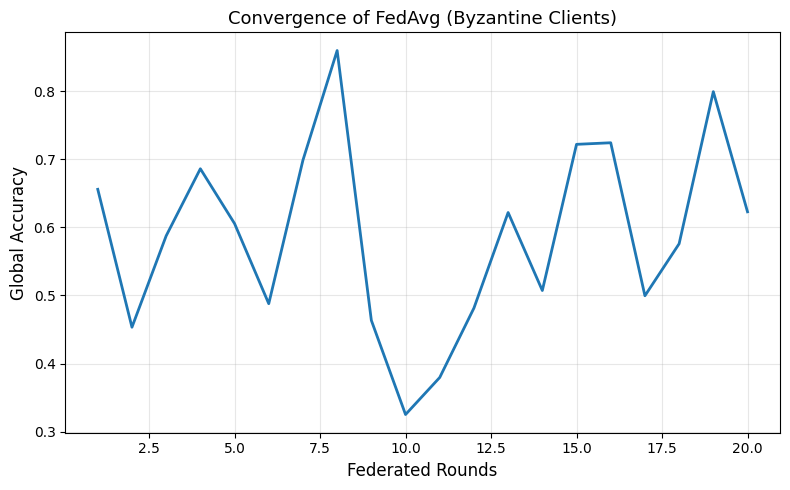

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(range(1, NUM_ROUNDS+1),
         accuracy_trust,
         linewidth=2)

plt.xlabel("Federated Rounds", fontsize=12)
plt.ylabel("Global Accuracy", fontsize=12)
plt.title("Convergence of FedAvg (Byzantine Clients)", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_test_tensor, y_test_tensor):

    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        _, preds = torch.max(outputs, 1)

    y_true = y_test_tensor.cpu().numpy()
    y_pred = preds.cpu().numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return acc, prec, rec, f1

In [ ]:
results = {}

results["IID"] = evaluate_model(iid_model, X_test_tensor, y_test_tensor)
results["Non-IID"] = evaluate_model(noniid_model, X_test_tensor, y_test_tensor)
results["Byzantine (FedAvg)"] = evaluate_model(byz_model, X_test_tensor, y_test_tensor)
results["Median"] = evaluate_model(median_model, X_test_tensor, y_test_tensor)
results["Trust-Median"] = evaluate_model(trust_model, X_test_tensor, y_test_tensor)

for key, value in results.items():
    print(f"{key}:")
    print(f" Accuracy: {value[0]:.4f}")
    print(f" Precision: {value[1]:.4f}")
    print(f" Recall: {value[2]:.4f}")
    print(f" F1 Score: {value[3]:.4f}")
    print()

IID:
 Accuracy: 0.7296
 Precision: 0.8733
 Recall: 0.5372
 F1 Score: 0.6652

Non-IID:
 Accuracy: 0.5085
 Precision: 0.5045
 Recall: 0.9628
 F1 Score: 0.6621

Byzantine (FedAvg):
 Accuracy: 0.4701
 Precision: 0.4810
 Recall: 0.7590
 F1 Score: 0.5889

Median:
 Accuracy: 0.8431
 Precision: 0.9904
 Recall: 0.6930
 F1 Score: 0.8154

Trust-Median:
 Accuracy: 0.8351
 Precision: 0.7703
 Recall: 0.9551
 F1 Score: 0.8528



In [ ]:
def convergence_stable(accuracy_list, threshold=0.005, patience=3):

    for i in range(len(accuracy_list) - patience):

        stable = True

        for j in range(patience):
            diff = abs(accuracy_list[i + j + 1] - accuracy_list[i + j])

            if diff > threshold:
                stable = False
                break

        if stable:
            return i + 1   # round number

    return len(accuracy_list)

In [ ]:
print("IID Convergence:", convergence_stable(accuracy_per_round))
print("Non-IID Convergence:", convergence_stable(accuracy_noniid))
print("Byzantine Convergence:", convergence_stable(accuracy_byzantine))
print("Median Convergence:", convergence_stable(accuracy_median))
print("Trust Convergence:", convergence_stable(accuracy_trust))

IID Convergence: 14
Non-IID Convergence: 3
Byzantine Convergence: 20
Median Convergence: 20
Trust Convergence: 20


In [ ]:
attack_tolerance_median = results["Median"][0] / results["Non-IID"][0]
attack_tolerance_trust = results["Trust-Median"][0] / results["Non-IID"][0]

print("Median Attack Tolerance:", attack_tolerance_median)
print("Trust Attack Tolerance:", attack_tolerance_trust)

Median Attack Tolerance: 1.6580416032470828
Trust Attack Tolerance: 1.2247590055809234


In [ ]:
import pandas as pd

df_results = pd.DataFrame(results,
                          index=["Accuracy", "Precision", "Recall", "F1"]).T

df_results

,Accuracy,Precision,Recall,F1
IID,0.729618,0.873322,0.537152,0.665176
Non-IID,0.508514,0.504461,0.962848,0.662054
Byzantine (FedAvg),0.470072,0.481033,0.759030,0.588871
Median,0.843137,0.990413,0.692982,0.815422
Trust-Median,0.835139,0.770287,0.955108,0.852799


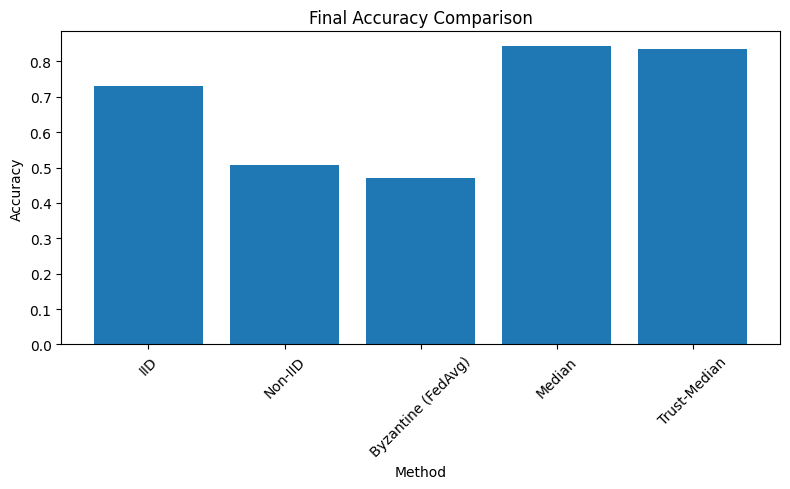

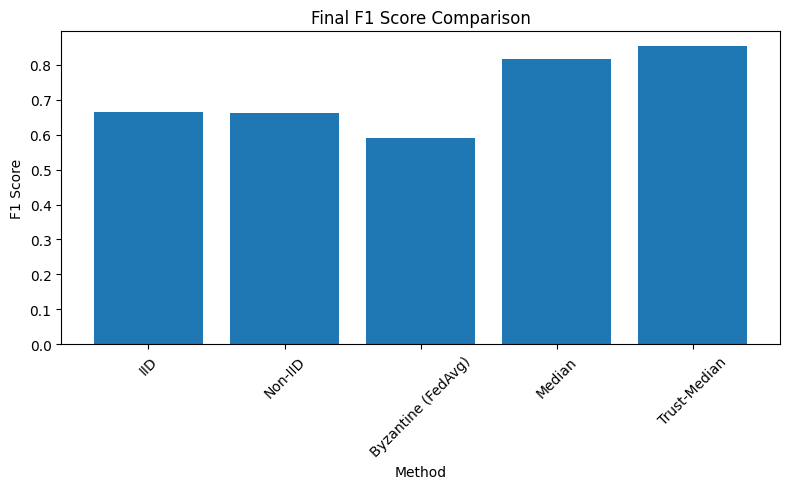

In [ ]:
import matplotlib.pyplot as plt

# Methods
methods = ["IID", "Non-IID", "Byzantine (FedAvg)", "Median", "Trust-Median"]

# Final Metrics
accuracy = [0.7296, 0.5085, 0.4701, 0.8431, 0.8351]
f1_scores = [0.6652, 0.6621, 0.5889, 0.8154, 0.8528]

# ----------------------------
# Accuracy Bar Graph
# ----------------------------
plt.figure(figsize=(8,5))
plt.bar(methods, accuracy)
plt.xlabel("Method")
plt.ylabel("Accuracy")
plt.title("Final Accuracy Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=300)
plt.show()


# ----------------------------
# F1 Score Bar Graph
# ----------------------------
plt.figure(figsize=(8,5))
plt.bar(methods, f1_scores)
plt.xlabel("Method")
plt.ylabel("F1 Score")
plt.title("Final F1 Score Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("f1_comparison.png", dpi=300)
plt.show()

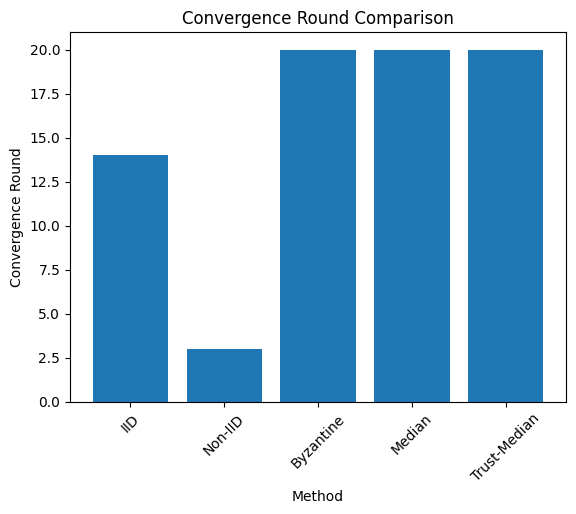

In [ ]:
methods = ["IID", "Non-IID", "Byzantine", "Median", "Trust-Median"]
convergence_rounds = [14, 3, 20, 20, 20]

plt.figure()
plt.bar(methods, convergence_rounds)
plt.xlabel("Method")
plt.ylabel("Convergence Round")
plt.title("Convergence Round Comparison")
plt.xticks(rotation=45)
plt.show()

<Figure size 640x480 with 0 Axes>

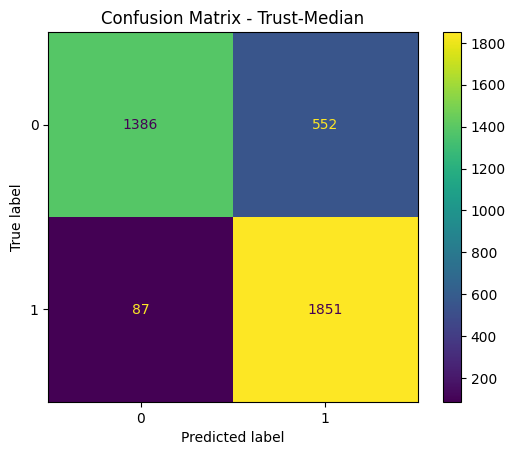

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import torch

trust_model.eval()
with torch.no_grad():
    outputs = trust_model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

cm = confusion_matrix(y_test_tensor.cpu(), preds.cpu())

plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Trust-Median")
plt.show()

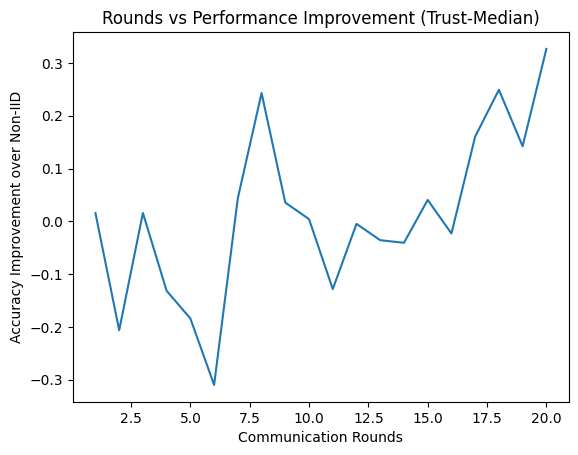

In [ ]:
baseline_acc = 0.5085  # Non-IID final accuracy

improvement = [acc - baseline_acc for acc in accuracy_trust]

rounds = range(1, len(accuracy_trust) + 1)

plt.figure()
plt.plot(rounds, improvement)
plt.xlabel("Communication Rounds")
plt.ylabel("Accuracy Improvement over Non-IID")
plt.title("Rounds vs Performance Improvement (Trust-Median)")
plt.show()

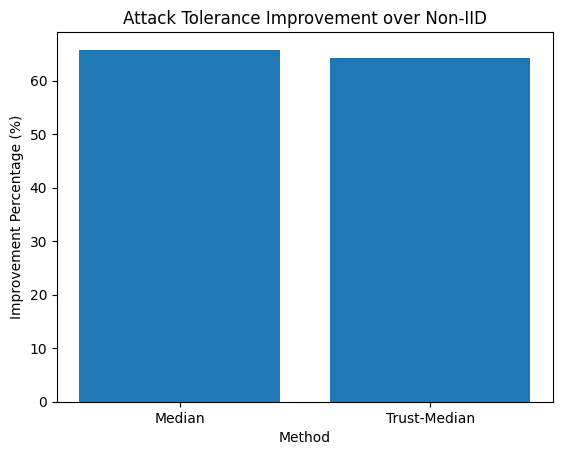

In [ ]:
median_acc = 0.8431
trust_acc = 0.8351
baseline_acc = 0.5085

attack_tolerance_median = ((median_acc - baseline_acc) / baseline_acc) * 100
attack_tolerance_trust = ((trust_acc - baseline_acc) / baseline_acc) * 100

methods = ["Median", "Trust-Median"]
tolerance_values = [attack_tolerance_median, attack_tolerance_trust]

plt.figure()
plt.bar(methods, tolerance_values)
plt.xlabel("Method")
plt.ylabel("Improvement Percentage (%)")
plt.title("Attack Tolerance Improvement over Non-IID")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch
import matplotlib.pyplot as plt
import numpy as np

trust_model.eval()

with torch.no_grad():
    outputs = trust_model(X_test_tensor)

    # Convert logits to probabilities
    probabilities = torch.softmax(outputs, dim=1)[:, 1]  # positive class prob

y_true = y_test_tensor.cpu().numpy()
y_scores = probabilities.cpu().numpy()

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)
avg_precision = average_precision_score(y_true, y_scores)

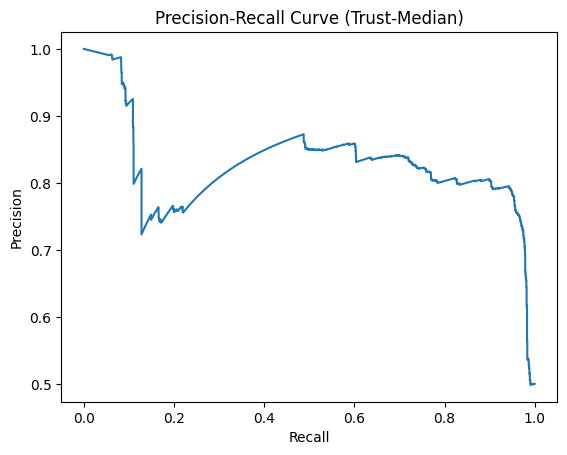

Average Precision (AP): 0.8267509746906232


In [ ]:
plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Trust-Median)")
plt.show()

print("Average Precision (AP):", avg_precision)

In [ ]:
plt.figure()
plt.plot(recall_trust, precision_trust)
plt.plot(recall_median, precision_median)
plt.plot(recall_byz, precision_byz)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend(["Trust-Median", "Median", "Byzantine FedAvg"])
plt.show()

NameError: name 'recall_trust' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch

def get_pr_curve(model, X_test_tensor, y_test_tensor):

    model.eval()
    with torch.no_grad():
        outputs = model(X_test_tensor)
        probs = torch.softmax(outputs, dim=1)[:, 1]

    y_true = y_test_tensor.cpu().numpy()
    y_scores = probs.cpu().numpy()

    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    avg_precision = average_precision_score(y_true, y_scores)

    return precision, recall, avg_precision

In [ ]:
precision_trust, recall_trust, ap_trust = get_pr_curve(trust_model, X_test_tensor, y_test_tensor)

precision_median, recall_median, ap_median = get_pr_curve(median_model, X_test_tensor, y_test_tensor)

precision_byz, recall_byz, ap_byz = get_pr_curve(byz_model, X_test_tensor, y_test_tensor)

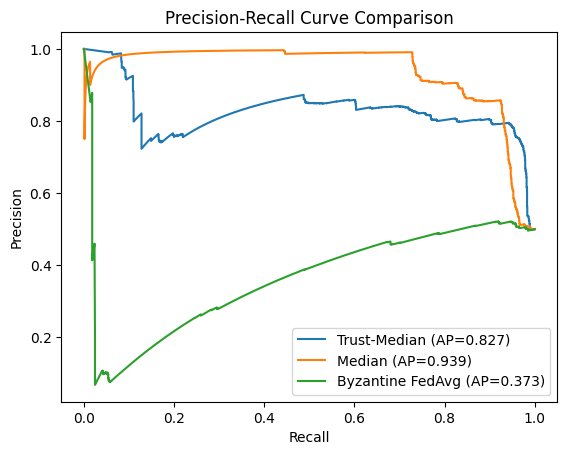

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(recall_trust, precision_trust)
plt.plot(recall_median, precision_median)
plt.plot(recall_byz, precision_byz)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend([
    f"Trust-Median (AP={ap_trust:.3f})",
    f"Median (AP={ap_median:.3f})",
    f"Byzantine FedAvg (AP={ap_byz:.3f})"
])

plt.show()